<center>
<a href="http://www.insa-toulouse.fr/" ><img src="http://www.math.univ-toulouse.fr/~besse/Wikistat/Images/logo-insa.jpg" style="float:left; max-width: 120px; display: inline" alt="INSA"/></a> 

</center>

# Projet Machine Learning — 4MA 2025-2026
## Prédiction du Risque de Maladie Cardiovasculaire
### INSA Toulouse
---

**Jeu de données** : *Cardiovascular Disease Risk Prediction Dataset* : 15 000 patients   
**Langage** : Python   
**Objectifs** :
- Partie 1 : Prédiction de `Heart_Disease_Risk` 
- Partie 2 : Prédiction de `Cholesterol_LDL` 

> Ce notebook vient compléter l'étude réalisée en R. Les conclusions sont comparables, > mais Python offre une exécution plus rapide, notamment pour la validation croisée.

### 0. Importation des bibliothèques et chargement des données

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import time

randomseed = 111 

In [3]:
df = pd.read_csv("healthcare_synthetic_data.csv")
print(df.shape)
df.head()


(15000, 19)


,Patient_ID,Age,Gender,Height_cm,Weight_kg,BMI,Systolic_BP,Diastolic_BP,Cholesterol_Total,Cholesterol_LDL,Cholesterol_HDL,Fasting_Blood_Sugar,Smoking_Status,Alcohol_Consumption,Physical_Activity_Level,Family_History,Stress_Level,Sleep_Hours,Heart_Disease_Risk
0,PID-00001,60,0,146.9,51.3,23.8,140,89,217,151,52,83,0,1,3,0,1,8,0
1,PID-00002,53,0,161.8,76.6,29.3,128,81,203,119,38,116,0,0,1,0,7,9,0
2,PID-00003,62,1,174.7,92.4,30.3,141,100,173,124,45,90,0,0,0,0,1,7,1
3,PID-00004,73,1,173.3,68.9,22.9,136,96,193,117,45,81,0,0,1,0,2,7,1
4,PID-00005,52,1,178.6,79.8,25.0,122,80,236,153,41,79,0,1,2,0,2,6,0


In [4]:
# Vérification des types de données et des valeurs manquantes
print("Types des variables :")
print(df.dtypes)
print("\nValeurs manquantes :")
print(df.isnull().sum())

# Prétraitement des données
df = df.drop(columns=["Patient_ID"])
for col in ["Gender", "Smoking_Status", "Family_History", "Heart_Disease_Risk"]:
    df[col] = pd.Categorical(df[col], ordered=False)
df["Alcohol_Consumption"] = pd.Categorical(
    df["Alcohol_Consumption"], categories=[0, 1, 2], ordered=True)
df["Physical_Activity_Level"] = pd.Categorical(
    df["Physical_Activity_Level"], categories=[0, 1, 2, 3], ordered=True)
print(df.dtypes)
df.describe()


Types des variables :
Patient_ID                  object
Age                          int64
Gender                       int64
Height_cm                  float64
Weight_kg                  float64
BMI                        float64
Systolic_BP                  int64
Diastolic_BP                 int64
Cholesterol_Total            int64
Cholesterol_LDL              int64
Cholesterol_HDL              int64
Fasting_Blood_Sugar          int64
Smoking_Status               int64
Alcohol_Consumption          int64
Physical_Activity_Level      int64
Family_History               int64
Stress_Level                 int64
Sleep_Hours                  int64
Heart_Disease_Risk           int64
dtype: object

Valeurs manquantes :
Patient_ID                 0
Age                        0
Gender                     0
Height_cm                  0
Weight_kg                  0
BMI                        0
Systolic_BP                0
Diastolic_BP               0
Cholesterol_Total          0
Cholesterol_LDL 

,Age,Height_cm,Weight_kg,BMI,Systolic_BP,Diastolic_BP,Cholesterol_Total,Cholesterol_LDL,Cholesterol_HDL,Fasting_Blood_Sugar,Stress_Level,Sleep_Hours
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,54.538133,165.336767,75.252573,27.446080,135.117667,90.541267,216.248000,140.355267,43.307867,99.670200,5.503667,6.506067
std,11.875294,9.186313,14.110559,4.134953,11.260634,8.443095,22.692222,17.914089,5.963153,15.261355,2.874277,1.212626
min,25.000000,138.500000,33.700000,14.500000,90.000000,60.000000,127.000000,70.000000,20.000000,60.000000,1.000000,4.000000
25%,46.000000,158.500000,65.200000,24.500000,127.000000,85.000000,201.000000,128.000000,39.000000,89.000000,3.000000,6.000000
50%,55.000000,164.700000,73.900000,27.200000,135.000000,91.000000,216.000000,140.000000,43.000000,99.000000,5.500000,7.000000
75%,63.000000,172.000000,83.900000,30.000000,143.000000,96.000000,231.000000,152.000000,47.000000,110.000000,8.000000,7.000000
max,85.000000,198.100000,150.100000,46.100000,182.000000,120.000000,303.000000,210.000000,68.000000,167.000000,10.000000,10.000000


### 1. Prédiction du risque d’accident cardiaque

In [5]:
X = df.drop(columns=["Heart_Disease_Risk"])
y = df["Heart_Disease_Risk"]

In [6]:
# Division en ensembles d'apprentissage et de test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=randomseed)

# Vérification des tailles des ensembles
print("Taille apprentissage :", X_train.shape[0])
print("Taille test :", X_test.shape[0])

# Normalisation
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)


Taille apprentissage : 12000
Taille test : 3000


Cette étape est essentielle car elle permet d'estimer les performances réelles du modèle sur des données qu'il n'a jamais vues durant l'apprentissage. Sans cette séparation, le modèle pourrait simplement mémoriser les données d'entraînement et afficher de bonnes performances sans pour autant être capable de généraliser à de nouveaux patients.On retient 20% des données pour le test, soit 3 000 patients.

#### 1.1 Modèle Linéaire Généralisé

##### 1.1.1 Sans pénalisation

Accuracy Train : 0.7361
Accuracy Test  : 0.7530

Matrice de confusion (Test) :
[[1426  335]
 [ 406  833]]

Rapport de classification :
              precision    recall  f1-score   support

           0       0.78      0.81      0.79      1761
           1       0.71      0.67      0.69      1239

    accuracy                           0.75      3000
   macro avg       0.75      0.74      0.74      3000
weighted avg       0.75      0.75      0.75      3000



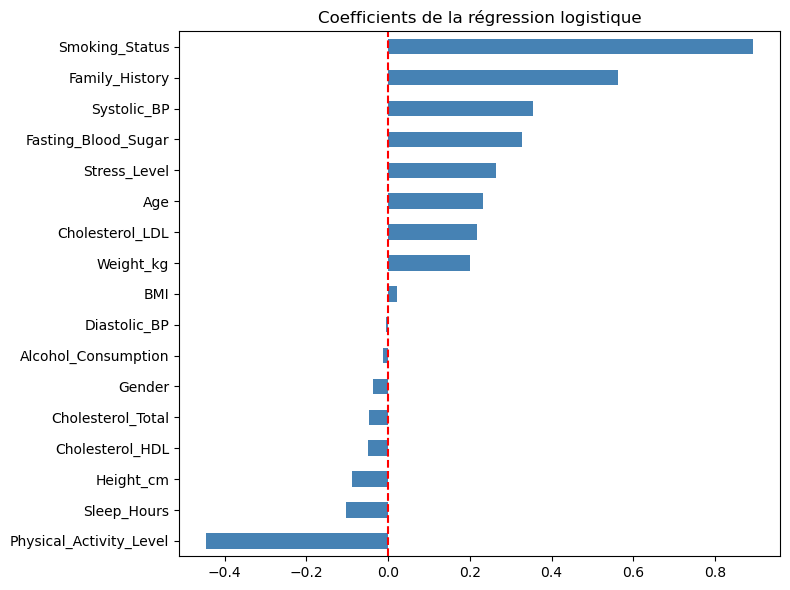

In [7]:
log_reg = LogisticRegression(penalty=None, max_iter=1000, random_state=randomseed)
log_reg.fit(X_train_scaled, y_train)

# Prédictions
y_pred_train = log_reg.predict(X_train_scaled)
y_pred_test  = log_reg.predict(X_test_scaled)

# Évaluation des performances
print(f"Accuracy Train : {accuracy_score(y_train, y_pred_train):.4f}")
print(f"Accuracy Test  : {accuracy_score(y_test, y_pred_test):.4f}")
print("\nMatrice de confusion (Test) :")
print(confusion_matrix(y_test, y_pred_test))
print("\nRapport de classification :")
print(classification_report(y_test, y_pred_test))

# Visualisation des coefficients
coef = pd.Series(log_reg.coef_[0], index=X.columns)
coef.sort_values().plot(kind='barh', figsize=(8, 6), color='steelblue')
plt.title("Coefficients de la régression logistique")
plt.axvline(0, color='red', linestyle='--')
plt.tight_layout()
plt.show()


##### 1.1.2 Lasso L1

C optimal : 21.5443
Accuracy Train : 0.7361
Accuracy Test  : 0.7530

Matrice de confusion (Test) :
[[1426  335]
 [ 406  833]]

Rapport de classification :
              precision    recall  f1-score   support

           0       0.78      0.81      0.79      1761
           1       0.71      0.67      0.69      1239

    accuracy                           0.75      3000
   macro avg       0.75      0.74      0.74      3000
weighted avg       0.75      0.75      0.75      3000


Variables éliminées (coef = 0) : 0
Variables conservées : 17


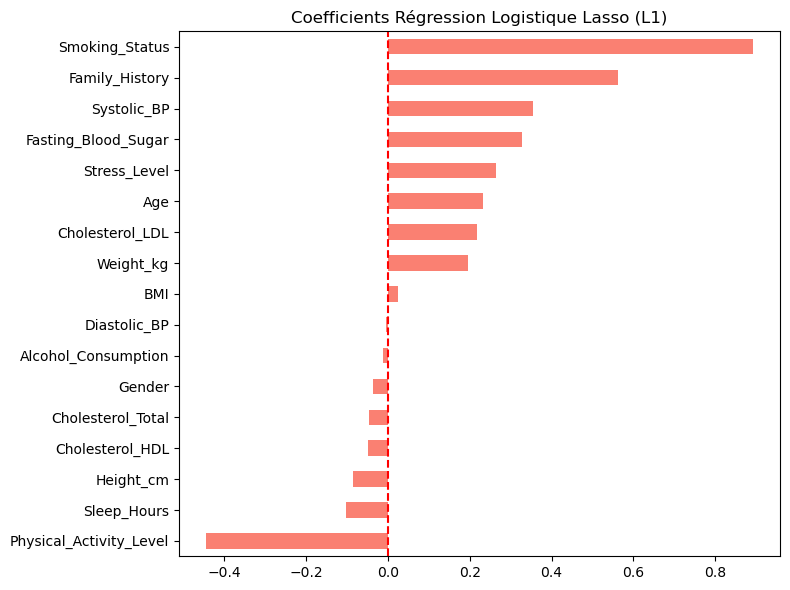

In [8]:
from sklearn.linear_model import LogisticRegressionCV

# ── Régression Logistique avec pénalisation L1 ────────────────
# On utilise LogisticRegressionCV pour optimiser C par validation croisée
# C = 1/lambda (plus C est petit, plus la pénalisation est forte)
log_lasso = LogisticRegressionCV(
    penalty='l1',
    solver='saga',
    cv=10,
    max_iter=1000,
    random_state=randomseed
)
log_lasso.fit(X_train_scaled, y_train)

# ── C optimal trouvé par validation croisée ───────────────────
print(f"C optimal : {log_lasso.C_[0]:.4f}")

# ── Prédictions ───────────────────────────────────────────────
y_pred_train_lasso = log_lasso.predict(X_train_scaled)
y_pred_test_lasso  = log_lasso.predict(X_test_scaled)

# ── Performances ──────────────────────────────────────────────
print(f"Accuracy Train : {accuracy_score(y_train, y_pred_train_lasso):.4f}")
print(f"Accuracy Test  : {accuracy_score(y_test, y_pred_test_lasso):.4f}")
print("\nMatrice de confusion (Test) :")
print(confusion_matrix(y_test, y_pred_test_lasso))
print("\nRapport de classification :")
print(classification_report(y_test, y_pred_test_lasso))

# ── Coefficients (variables sélectionnées) ────────────────────
coef_lasso = pd.Series(log_lasso.coef_[0], index=X.columns)
print(f"\nVariables éliminées (coef = 0) : {sum(coef_lasso == 0)}")
print(f"Variables conservées : {sum(coef_lasso != 0)}")

coef_lasso.sort_values().plot(kind='barh', figsize=(8, 6), color='salmon')
plt.title("Coefficients Régression Logistique Lasso (L1)")
plt.axvline(0, color='red', linestyle='--')
plt.tight_layout()
plt.show()

##### 1.1.3 Ridge L2

In [9]:
# ── Régression Logistique avec pénalisation L2 ────────────────
# L2 est le penalty par défaut de LogisticRegressionCV
log_ridge = LogisticRegressionCV(
    penalty='l2',
    solver='saga',
    cv=10,
    max_iter=1000,
    random_state=randomseed
)
log_ridge.fit(X_train_scaled, y_train)

# ── C optimal trouvé par validation croisée ───────────────────
print(f"C optimal : {log_ridge.C_[0]:.4f}")

# ── Prédictions ───────────────────────────────────────────────
y_pred_train_ridge = log_ridge.predict(X_train_scaled)
y_pred_test_ridge  = log_ridge.predict(X_test_scaled)

# ── Performances ──────────────────────────────────────────────
print(f"Accuracy Train : {accuracy_score(y_train, y_pred_train_ridge):.4f}")
print(f"Accuracy Test  : {accuracy_score(y_test, y_pred_test_ridge):.4f}")
print("\nMatrice de confusion (Test) :")
print(confusion_matrix(y_test, y_pred_test_ridge))
print("\nRapport de classification :")
print(classification_report(y_test, y_pred_test_ridge))

# ── Coefficients ────────────────

C optimal : 2.7826
Accuracy Train : 0.7361
Accuracy Test  : 0.7530

Matrice de confusion (Test) :
[[1426  335]
 [ 406  833]]

Rapport de classification :
              precision    recall  f1-score   support

           0       0.78      0.81      0.79      1761
           1       0.71      0.67      0.69      1239

    accuracy                           0.75      3000
   macro avg       0.75      0.74      0.74      3000
weighted avg       0.75      0.75      0.75      3000



In [10]:
# ── Tableau comparatif des 3 modèles ─────────────────────────
resultats_logit = pd.DataFrame({
    "Modèle": [
        "Logistique (sans pénalisation)",
        "Logistique Lasso (L1)",
        "Logistique Ridge (L2)"
    ],
    "C optimal": ["-", "21.5443", "2.7826"],
    "Accuracy Train": [0.7361, 0.7361, 0.7361],
    "Accuracy Test":  [0.7530, 0.7530, 0.7530],
    "F1-score (classe 1)": [0.69, 0.69, 0.69],
    "Variables éliminées": ["-", "0", "-"]
})

print(resultats_logit.to_string(index=False))

                        Modèle C optimal  Accuracy Train  Accuracy Test  F1-score (classe 1) Variables éliminées
Logistique (sans pénalisation)         -          0.7361          0.753                 0.69                   -
         Logistique Lasso (L1)   21.5443          0.7361          0.753                 0.69                   0
         Logistique Ridge (L2)    2.7826          0.7361          0.753                 0.69                   -


## Gradient boosting


In [11]:
# ============================================================
# 1.2 Gradient Boosting (Modèle non-linéaire)
# ============================================================

from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import roc_curve, roc_auc_score
import time

print("\n" + "="*60)
print("OPTIMISATION DU GRADIENT BOOSTING")
print("="*60)

# Grille de paramètres à explorer
paramGrid = [
    {
        'n_estimators': list(range(100, 601, 50)),  # 100 à 550 par pas de 50
        'learning_rate': [0.05, 0.1, 0.2, 0.3]
    }
]

# Initialisation du modèle
gbm = GradientBoostingClassifier(random_state=randomseed)

# GridSearchCV avec validation croisée 5 folds
gbm_cv = GridSearchCV(gbm, paramGrid, cv=5, n_jobs=-1, verbose=1)

# Entraînement (utilisation de X_train non normalisé car les arbres sont insensibles à l'échelle)
start_time = time.time()
gbm_opt = gbm_cv.fit(X_train, y_train)
end_time = time.time()

# Affichage des résultats
print(f"\nTemps d'exécution : {end_time - start_time:.2f} secondes")
print(f"Meilleur score (validation croisée) : {gbm_opt.best_score_:.4f}")
print(f"Meilleurs paramètres : {gbm_opt.best_params_}")


OPTIMISATION DU GRADIENT BOOSTING
Fitting 5 folds for each of 44 candidates, totalling 220 fits

Temps d'exécution : 883.36 secondes
Meilleur score (validation croisée) : 0.7303
Meilleurs paramètres : {'learning_rate': 0.1, 'n_estimators': 100}


In [15]:
# Prédictions et évaluation
# =========================

yChap = gbm_opt.predict(X_test)  # ← Syntaxe comme dans votre code : yChap

# Probabilités pour la courbe ROC
probas_ = gbm_opt.predict_proba(X_test)  # ← Syntaxe comme dans votre code : probas_

print("\n" + "="*60)
print("PERFORMANCES DU GRADIENT BOOSTING")
print("="*60)

# Matrice de confusion (comme dans votre code)
table = pd.crosstab(yChap, y_test)
print("Matrice de confusion (Test) :")
print(table)

# Erreur de test (comme dans votre code)
print(f"Erreur de test gbm opt = {(1 - gbm_opt.score(X_test, y_test)):.4f}")
print(f"Accuracy Test = {gbm_opt.score(X_test, y_test):.4f}")

# Rapport de classification
print("\nRapport de classification :")
print(classification_report(y_test, yChap))


PERFORMANCES DU GRADIENT BOOSTING
Matrice de confusion (Test) :
Heart_Disease_Risk     0    1
row_0                        
0                   1406  418
1                    355  821
Erreur de test gbm opt = 0.2577
Accuracy Test = 0.7423

Rapport de classification :
              precision    recall  f1-score   support

           0       0.77      0.80      0.78      1761
           1       0.70      0.66      0.68      1239

    accuracy                           0.74      3000
   macro avg       0.73      0.73      0.73      3000
weighted avg       0.74      0.74      0.74      3000




IMPORTANCE DES VARIABLES - GRADIENT BOOSTING
               Variable  Importance
         Smoking_Status    0.378506
         Family_History    0.141631
            Systolic_BP    0.098823
Physical_Activity_Level    0.085050
    Fasting_Blood_Sugar    0.079363
                    Age    0.061461
           Stress_Level    0.035612
                    BMI    0.031437
        Cholesterol_LDL    0.030952
              Weight_kg    0.014490
      Cholesterol_Total    0.011710
              Height_cm    0.009852
           Diastolic_BP    0.008260
            Sleep_Hours    0.007146
        Cholesterol_HDL    0.004516
    Alcohol_Consumption    0.000937
                 Gender    0.000254


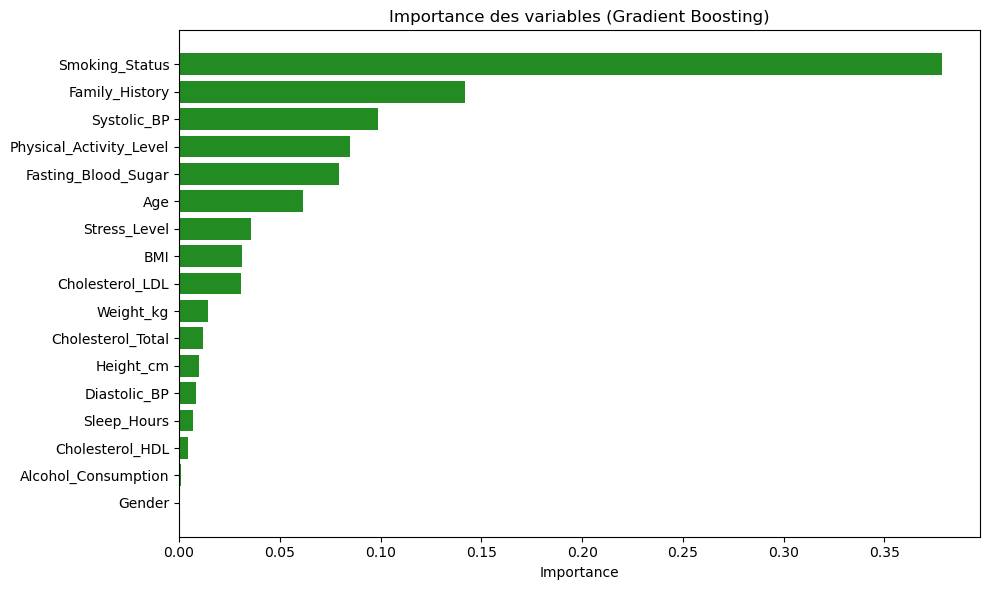

In [17]:
# Importance des variables
# ========================

feature_importance = pd.DataFrame({
    'Variable': X.columns,
    'Importance': gbm_opt.best_estimator_.feature_importances_
}).sort_values('Importance', ascending=False)

print("\n" + "="*60)
print("IMPORTANCE DES VARIABLES - GRADIENT BOOSTING")
print("="*60)
print(feature_importance.to_string(index=False))

# Visualisation
plt.figure(figsize=(10, 6))
plt.barh(feature_importance['Variable'], feature_importance['Importance'], color='forestgreen')
plt.xlabel('Importance')
plt.title('Importance des variables (Gradient Boosting)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## Comparaiason des méthodes (RL SANS PENALISATION ,LASSO ,RIDGE ET GB)

In [19]:
# Tableau comparatif final
# ========================

resultats_complet = pd.DataFrame({
    "Modèle": [
        "Régression Logistique (sans pénalisation)",
        "Régression Logistique Lasso (L1)",
        "Régression Logistique Ridge (L2)",
        "Gradient Boosting"
    ],
    "Accuracy Train": [
        accuracy_score(y_train, y_pred_train),
        accuracy_score(y_train, y_pred_train_lasso),
        accuracy_score(y_train, y_pred_train_ridge),
        gbm_opt.score(X_train, y_train)
    ],
    "Accuracy Test": [
        accuracy_score(y_test, y_pred_test),
        accuracy_score(y_test, y_pred_test_lasso),
        accuracy_score(y_test, y_pred_test_ridge),
        gbm_opt.score(X_test, y_test)
    ],
    "Erreur Test": [
        1 - accuracy_score(y_test, y_pred_test),
        1 - accuracy_score(y_test, y_pred_test_lasso),
        1 - accuracy_score(y_test, y_pred_test_ridge),
        1 - gbm_opt.score(X_test, y_test)
    ]
})

print("\n" + "="*60)
print("TABLEAU COMPARATIF DES MODÈLES")
print("="*60)
print(resultats_complet.to_string(index=False))

# Meilleur modèle
best_acc = resultats_complet.loc[resultats_complet['Accuracy Test'].idxmax(), 'Modèle']
print(f"\n🏆 Meilleur modèle selon l'accuracy test : {best_acc}")


TABLEAU COMPARATIF DES MODÈLES
                                   Modèle  Accuracy Train  Accuracy Test  Erreur Test
Régression Logistique (sans pénalisation)        0.736083       0.753000     0.247000
         Régression Logistique Lasso (L1)        0.736083       0.753000     0.247000
         Régression Logistique Ridge (L2)        0.736083       0.753000     0.247000
                        Gradient Boosting        0.752500       0.742333     0.257667

🏆 Meilleur modèle selon l'accuracy test : Régression Logistique (sans pénalisation)
